In [4]:
import pandas as pd
import numpy as np

# 1. Đọc tệp dữ liệu cấp cao (đã tổng hợp sẵn)
BASE_DATA = "data/"
sales = pd.read_csv(BASE_DATA + 'sales.csv')

# 2. Xử lý thời gian để gom cụm theo Năm
sales['Date'] = pd.to_datetime(sales['Date'])
sales['year'] = sales['Date'].dt.year

# 3. Tính Tổng Doanh thu và Giá vốn theo từng năm
financial_yearly = sales.groupby('year').agg(
    Revenue=('Revenue', 'sum'),
    COGS=('COGS', 'sum')
).reset_index()

# 4. Tính Gross Profit và Gross Margin (%)
financial_yearly['Gross_Profit'] = financial_yearly['Revenue'] - financial_yearly['COGS']
financial_yearly['Gross_Margin (%)'] = (financial_yearly['Gross_Profit'] / financial_yearly['Revenue']) * 100

print("--- Bảng kết quả Gross Margin hàng năm ---")
print(financial_yearly)

# 5. Tính Revenue CAGR
# Sắp xếp theo năm để đảm bảo thứ tự
financial_yearly = financial_yearly.sort_values('year')

# Lấy giá trị đầu và cuối
beginning_revenue = financial_yearly['Revenue'].iloc[0]
ending_revenue = financial_yearly['Revenue'].iloc[-1]

# Tính số năm (n)
start_year = financial_yearly['year'].iloc[0]
end_year = financial_yearly['year'].iloc[-1]
n_years = end_year - start_year

if n_years > 0:
    revenue_cagr = (ending_revenue / beginning_revenue) ** (1 / n_years) - 1
    print(f"\n--- Chỉ số CAGR ---")
    print(f"Giai đoạn: {start_year} - {end_year} ({n_years} năm)")
    print(f"Revenue CAGR: {revenue_cagr:.2%}")
else:
    print("\nKhông đủ dữ liệu thời gian để tính CAGR (cần ít nhất 2 năm).")

--- Bảng kết quả Gross Margin hàng năm ---
    year       Revenue          COGS  Gross_Profit  Gross_Margin (%)
0   2012  7.414977e+08  5.874619e+08  1.540358e+08         20.773606
1   2013  1.657169e+09  1.465980e+09  1.911893e+08         11.537101
2   2014  1.871846e+09  1.574607e+09  2.972384e+08         15.879428
3   2015  1.889934e+09  1.665442e+09  2.244920e+08         11.878300
4   2016  2.104641e+09  1.780559e+09  3.240813e+08         15.398414
5   2017  1.911164e+09  1.694386e+09  2.167785e+08         11.342747
6   2018  1.850122e+09  1.542176e+09  3.079467e+08         16.644665
7   2019  1.136801e+09  1.005203e+09  1.315986e+08         11.576213
8   2020  1.054512e+09  8.860851e+08  1.684271e+08         15.972036
9   2021  1.043040e+09  9.411301e+08  1.019097e+08          9.770451
10  2022  1.169749e+09  1.020420e+09  1.493287e+08         12.765874

--- Chỉ số CAGR ---
Giai đoạn: 2012 - 2022 (10 năm)
Revenue CAGR: 4.66%


In [8]:
import pandas as pd
import numpy as np

# 1. Đọc tệp dữ liệu cấp cao (đã tổng hợp sẵn)
BASE_DATA = "data/"
sales = pd.read_csv(BASE_DATA + 'sales.csv')

# 2. Xử lý thời gian để gom cụm theo Năm
sales['Date'] = pd.to_datetime(sales['Date'])
sales['year'] = sales['Date'].dt.year

# 3. Tính Tổng Doanh thu và Giá vốn theo từng năm
financial_yearly = sales.groupby('year').agg(
    Revenue=('Revenue', 'sum'),
    COGS=('COGS', 'sum')
).reset_index()

financial_yearly['Gross_Margin'] = (
    (financial_yearly['Revenue'] - financial_yearly['COGS']) 
    / financial_yearly['Revenue']
)   

financial_yearly = financial_yearly.sort_values('year')

start_revenue = financial_yearly['Revenue'].iloc[0]
end_revenue = financial_yearly['Revenue'].iloc[-1]
num_years = financial_yearly['year'].iloc[-1] - financial_yearly['year'].iloc[0]

cagr = (end_revenue / start_revenue) ** (1 / num_years) - 1

print(financial_yearly['Gross_Margin']*100)
print("Revenue CAGR:", cagr*100)

0     20.773606
1     11.537101
2     15.879428
3     11.878300
4     15.398414
5     11.342747
6     16.644665
7     11.576213
8     15.972036
9      9.770451
10    12.765874
Name: Gross_Margin, dtype: float64
Revenue CAGR: 4.6642289449912555


/var/folders/yf/z8cyz0qn4r557bdjflrksgkw0000gn/T/ipykernel_27416/139133220.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  current_inv.groupby(['delivery_bucket', 'split_segment'])


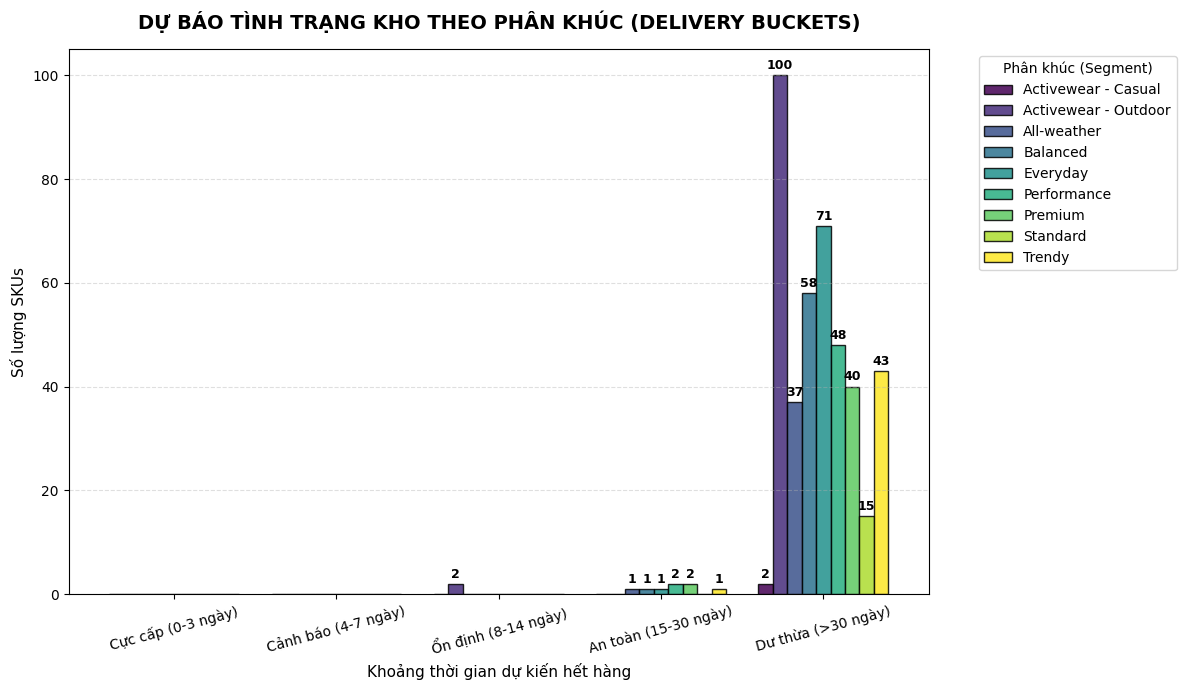

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
BASE_DATA = "data/"
inventory = pd.read_csv(BASE_DATA + 'inventory.csv')

inventory['split_segment'] = inventory.apply(
    lambda x: f"Activewear - {x['category']}" if x['segment'] == 'Activewear' else x['segment'], 
    axis=1
)
# 2. Lấy snapshot mới nhất
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
latest_date = inventory['snapshot_date'].max()

current_inv = inventory[inventory['snapshot_date'] == latest_date].copy()

# 3. Tính toán tồn kho & velocity (FIX: dùng current_inv, không dùng inventory)
current_inv['stock_level'] = current_inv['stock_on_hand']
current_inv['daily_sales_velocity'] = current_inv['units_sold'] / 30

# 4. Tính Days of Supply (FIX: xử lý chia cho 0 đúng cách)
current_inv['days_of_supply'] = np.where(
    current_inv['daily_sales_velocity'] == 0,
    np.inf,
    current_inv['stock_level'] / current_inv['daily_sales_velocity']
)

# 5. Định nghĩa Delivery Buckets
bins = [0, 3, 7, 14, 30, float('inf')]
labels = [
    'Cực cấp (0-3 ngày)',
    'Cảnh báo (4-7 ngày)',
    'Ổn định (8-14 ngày)',
    'An toàn (15-30 ngày)',
    'Dư thừa (>30 ngày)'
]

current_inv['delivery_bucket'] = pd.cut(
    current_inv['days_of_supply'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# 6. Tổng hợp dữ liệu theo cả Bucket và Segment
# Chúng ta đếm số lượng SKU cho mỗi cặp (Bucket, Segment)
bucket_segment_counts = (
    current_inv.groupby(['delivery_bucket', 'split_segment'])
    .size()
    .unstack(fill_value=0) # Chuyển Segment thành các cột để vẽ group bar
)

# Đảm bảo thứ tự các Bucket đúng như định nghĩa ban đầu
bucket_segment_counts = bucket_segment_counts.reindex(labels)

# 7. Vẽ biểu đồ Grouped Bar Chart
# Sử dụng trực tiếp phương thức plot của pandas để vẽ group bar dễ dàng hơn
ax = bucket_segment_counts.plot(
    kind='bar', 
    figsize=(12, 7), 
    width=0.8, 
    edgecolor='black',
    alpha=0.85,
    colormap='viridis' # Hoặc chọn bảng màu khác như 'tab10', 'Set3'
)

# Hiển thị số lượng trên đầu mỗi cột
for p in ax.patches:
    y_value = p.get_height()
    if y_value > 0: # Chỉ hiện số nếu giá trị lớn hơn 0
        ax.annotate(
            f'{int(y_value)}', 
            (p.get_x() + p.get_width() / 2., y_value), 
            ha='center', va='center', 
            xytext=(0, 7), 
            textcoords='offset points',
            fontsize=9,
            fontweight='bold'
        )

# Tinh chỉnh giao diện
plt.title('DỰ BÁO TÌNH TRẠNG KHO THEO PHÂN KHÚC (DELIVERY BUCKETS)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Khoảng thời gian dự kiến hết hàng', fontsize=11)
plt.ylabel('Số lượng SKUs', fontsize=11)
plt.xticks(rotation=15) # Xoay nhẹ nhãn trục X để dễ đọc
plt.legend(title="Phân khúc (Segment)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

/var/folders/yf/z8cyz0qn4r557bdjflrksgkw0000gn/T/ipykernel_27416/3131000500.py:9: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(BASE_DATA + 'order_items.csv')


BẢNG THÔNG SỐ VẼ BIỂU ĐỒ PARETO:
       split_segment revenue_M cum_pct abc
            Everyday 5,147.45M  32.83%   A
            Balanced 4,900.32M  64.08%   A
         Performance 2,285.03M  78.65%   A
Activewear - Outdoor 1,899.18M  90.76%   B
             Premium   454.21M  93.66%   B
         All-weather   408.77M  96.26%   C
              Trendy   328.71M  98.36%   C
            Standard   225.67M  99.80%   C
 Activewear - Casual    31.52M 100.00%   C


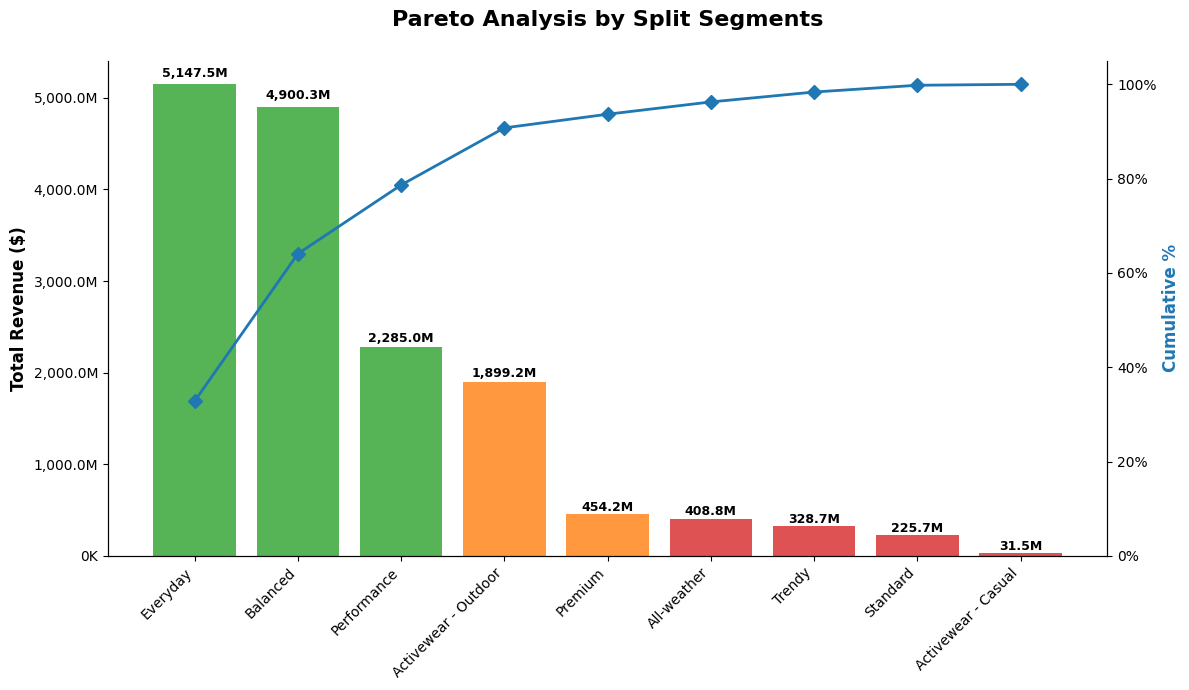

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
from matplotlib.patches import Patch

# 1. CHUẨN BỊ DỮ LIỆU
BASE_DATA = "data/"
order_items = pd.read_csv(BASE_DATA + 'order_items.csv')
products = pd.read_csv(BASE_DATA + 'products.csv')

# Merge dữ liệu
df = order_items.merge(products[['product_id', 'segment', 'category']], on='product_id', how='inner')

# Tạo cột split_segment
df['split_segment'] = df.apply(
    lambda x: f"Activewear - {x['category']}" if x['segment'] == 'Activewear' else x['segment'], 
    axis=1
)

# Tính doanh thu
df['revenue'] = (df['quantity'] * df['unit_price']) - df['discount_amount'].fillna(0)

# --- THAY ĐỔI LOGIC: Groupby theo split_segment (không theo product_id) ---
seg_revenue = df.groupby('split_segment')['revenue'].sum().reset_index()

# Sắp xếp giảm dần theo doanh thu của Phân khúc
data = seg_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)

# Tính toán Pareto cho các Segment
data['cum_pct'] = data['revenue'].cumsum() / data['revenue'].sum() * 100
data['abc'] = pd.cut(data['cum_pct'], bins=[0, 80, 95, 100.01], labels=['A', 'B', 'C'], include_lowest=True)

# Map màu sắc
color_map = {'A': '#2ca02c', 'B': '#ff7f0e', 'C': '#d62728'}
data['color'] = data['abc'].map(color_map)

# --- IN BẢNG THÔNG SỐ ---
print("BẢNG THÔNG SỐ VẼ BIỂU ĐỒ PARETO:")
# Tạo một bản sao để format mà không ảnh hưởng đến dữ liệu vẽ biểu đồ
display_table = data.copy()

# Định dạng doanh thu sang đơn vị Triệu (M) để dễ đọc
display_table['revenue_M'] = display_table['revenue'].apply(lambda x: f"{x/1e6:,.2f}M")
# Định dạng phần trăm tích lũy
display_table['cum_pct'] = display_table['cum_pct'].apply(lambda x: f"{x:.2f}%")

# Chỉ in các cột quan trọng
columns_to_show = ['split_segment', 'revenue_M', 'cum_pct', 'abc']
print(display_table[columns_to_show].to_string(index=False))

# --- DỰNG BIỂU ĐỒ DUY NHẤT ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# Vẽ Bar: Trục X bây giờ là tên các Phân khúc
bars = ax1.bar(data['split_segment'], data['revenue'], color=data['color'], width=0.8, alpha=0.8)
ax1.set_ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right') # Xoay tên segment cho dễ đọc

# Format trục Y1
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}K".format(x/1e3) if x < 1e6 else "{:,.1f}M".format(x/1e6)))

# Trục Y2 cho đường % tích lũy
ax2 = ax1.twinx()
ax2.plot(data['split_segment'], data['cum_pct'], color='#1f77b4', marker='D', ms=7, linewidth=2, label='Cumulative %')
ax2.set_ylabel('Cumulative %', fontsize=12, fontweight='bold', color='#1f77b4')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylim(0, 105)

# Thêm nhãn giá trị doanh thu lên đầu mỗi cột (tùy chọn)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + (height*0.01),
             "{:,.1f}M".format(height/1e6) if height >= 1e6 else "{:,.0f}K".format(height/1e3),
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Styling
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
plt.title('Pareto Analysis by Split Segments', fontsize=16, fontweight='bold', pad=25)


plt.tight_layout()
plt.show()